<a href="https://colab.research.google.com/github/jessicalewinter/deep-learning-specialization/blob/main/course-notebooks/machine-learning/class_5_decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Decision Tree Classifier with Scikit-Learn
This notebook demonstrates how to build and visualize a Decision Tree using the `sklearn` library.

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load the iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Decision Tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Model Accuracy: 1.00


In [3]:
import pandas as pd

# Convert the iris dataset to a pandas DataFrame for better visualization
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

print("Iris Dataset Features:", iris.feature_names)
print("Iris Target Names:", iris.target_names)
display(iris_df.head())

Iris Dataset Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Iris Target Names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


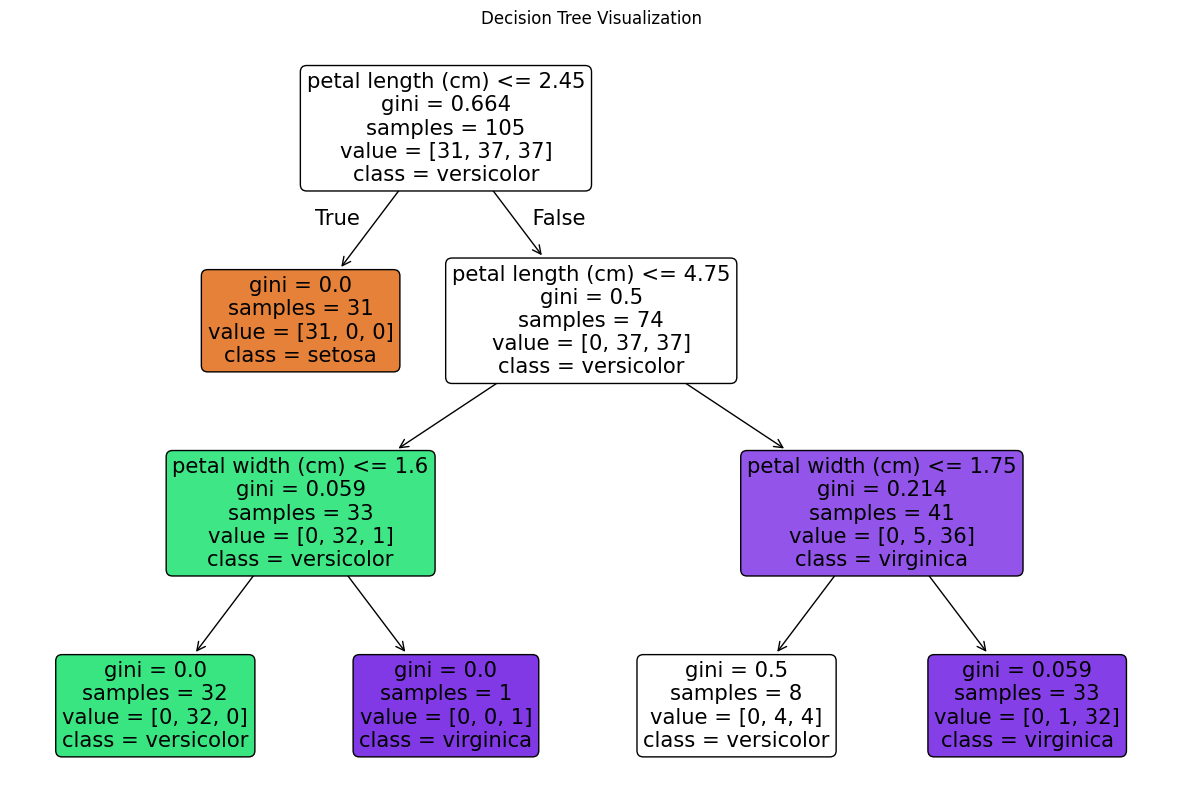

In [2]:
# Visualize the trained Decision Tree
plt.figure(figsize=(15, 10))
plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

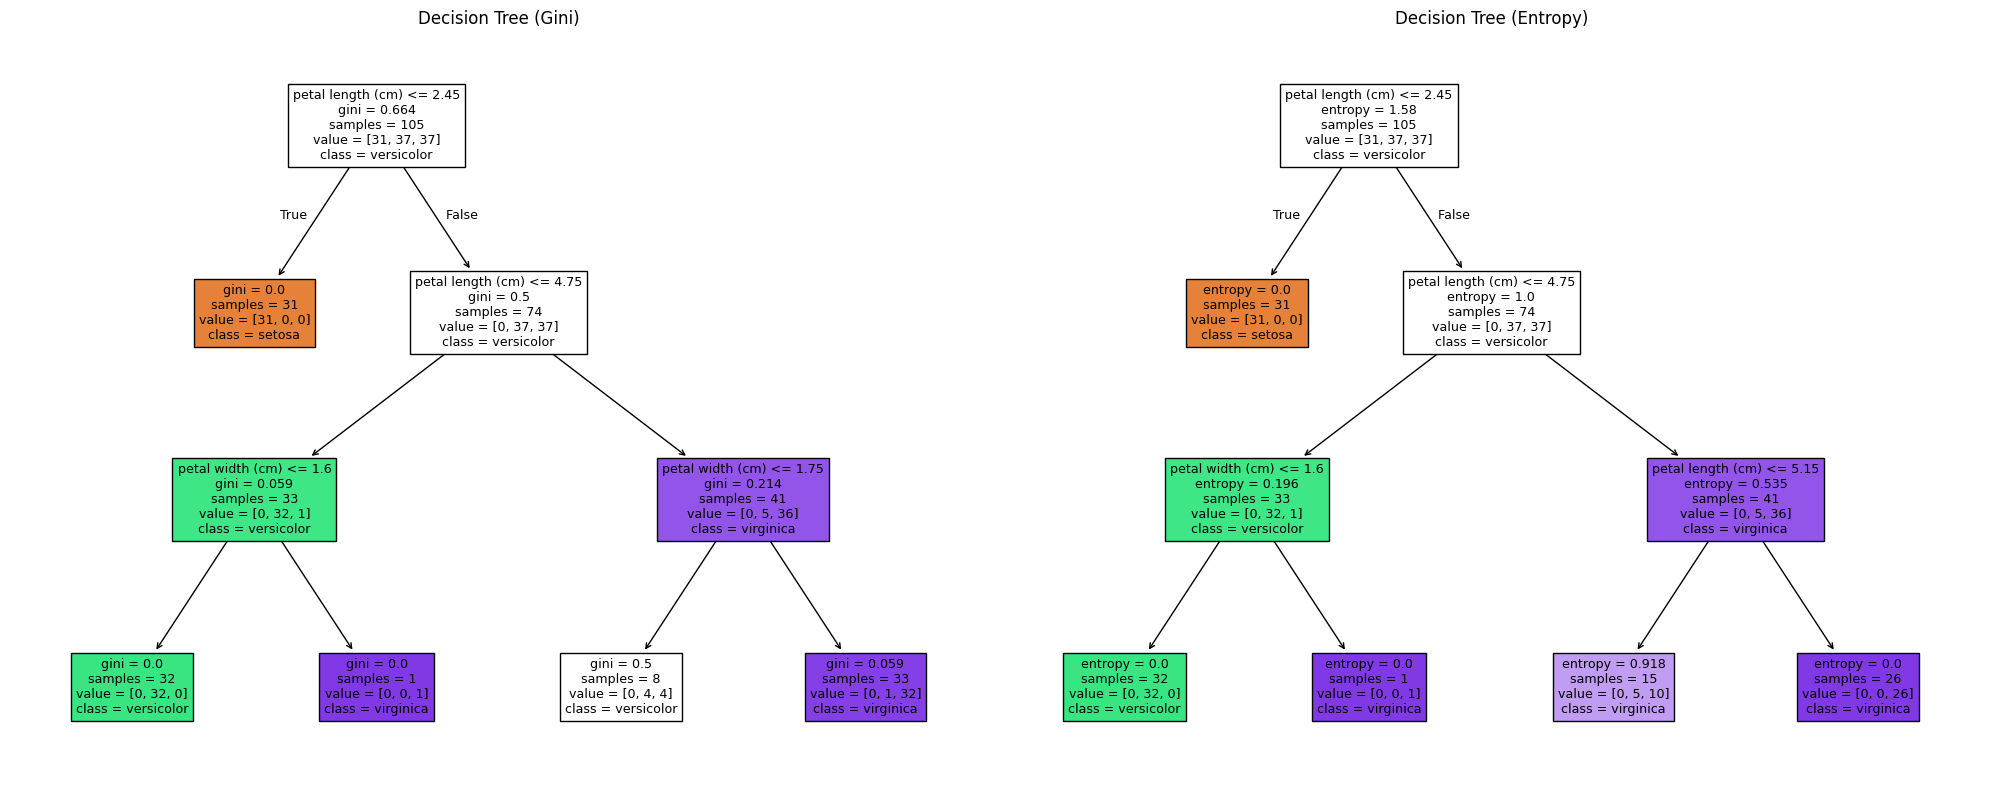

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train two models with different criteria
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

clf_gini.fit(X_train, y_train)
clf_entropy.fit(X_train, y_train)

# Create a side-by-side visualization
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

# Plot Gini Tree
plot_tree(clf_gini,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, ax=axes[0])
axes[0].set_title("Decision Tree (Gini)")

iris.data
# Plot Entropy Tree
plot_tree(clf_entropy,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, ax=axes[1])
axes[1].set_title("Decision Tree (Entropy)")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

# Create a DataFrame to compare feature importances
importances = pd.DataFrame({
    'Feature': iris.feature_names,
    'Gini Importance': clf_gini.feature_importances_,
    'Entropy Importance': clf_entropy.feature_importances_
})

print("Feature Importances for both models:")
display(importances.sort_values(by='Gini Importance', ascending=False))

Feature Importances for both models:


,Feature,Gini Importance,Entropy Importance
2,petal length (cm),0.925108,0.957507
3,petal width (cm),0.074892,0.042493
1,sepal width (cm),0.000000,0.000000
0,sepal length (cm),0.000000,0.000000
